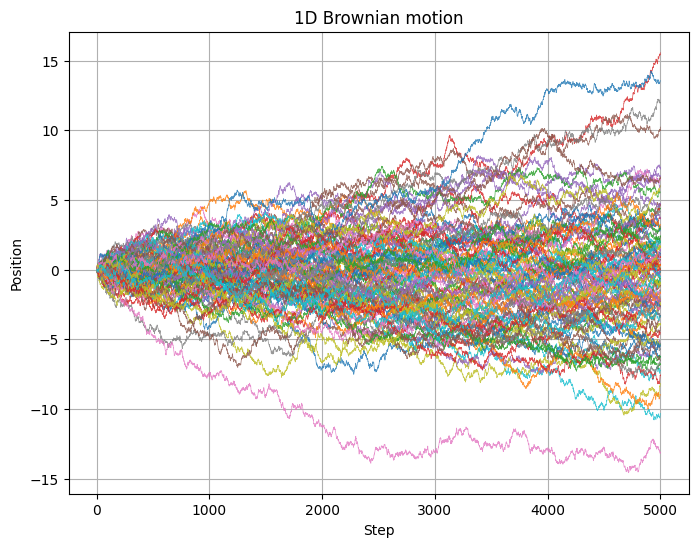

In [17]:
import numpy as np

# Simulate Brownian motion (1D or 2D) and plot results
import matplotlib.pyplot as plt

def simulate_brownian(n_steps=1000, dt=1.0, dim=2, n_paths=1, sigma=1.0, seed=None):
    """
    Returns positions with shape (n_paths, n_steps+1, dim).
    Increments are normal with std = sigma * sqrt(dt).
    """
    rng = np.random.default_rng(seed)
    std = sigma * np.sqrt(dt)
    increments = rng.normal(loc=0.0, scale=std, size=(n_paths, n_steps, dim))
    starts = np.zeros((n_paths, 1, dim))
    positions = np.concatenate([starts, np.cumsum(increments, axis=1)], axis=1)
    return positions

def plot_brownian(positions, show_mean_squared_displacement=True, figsize=(8,6)):
    """
    Plot 1D or 2D Brownian paths. If multiple paths are given, plot them together.
    Also optionally plots mean squared displacement (MSD) vs time (for 1D or 2D).
    """
    n_paths, n_times, dim = positions.shape
    times = np.arange(n_times)
    plt.figure(figsize=figsize)
    if dim == 1:
        for i in range(n_paths):
            plt.plot(times, positions[i, :, 0], alpha=0.8, label=f'path {i+1}', linewidth=.5)
        plt.xlabel('Step')
        plt.ylabel('Position')
        plt.title('1D Brownian motion')
        if n_paths <= 10:
            plt.legend()
    elif dim == 2:
        for i in range(n_paths):
            plt.plot(positions[i, :, 0], positions[i, :, 1], alpha=0.8, label=f'path {i+1}')
            plt.scatter(positions[i, 0, 0], positions[i, 0, 1], c='green', s=30, marker='o')  # start
            plt.scatter(positions[i, -1, 0], positions[i, -1, 1], c='red', s=30, marker='x')  # end
        plt.xlabel('x')
        plt.ylabel('y')
        plt.title('2D Brownian motion')
        plt.axis('equal')
        if n_paths <= 10:
            plt.legend()
    else:
        raise ValueError("dim must be 1 or 2")

    plt.grid(True)
    plt.show()

    if show_mean_squared_displacement:
        pass
        # # MSD: average squared displacement from origin
        # displacements = positions - positions[:, 0:1, :]
        # sq_disp = np.sum(displacements**2, axis=2)  # shape (n_paths, n_times)
        # msd = sq_disp.mean(axis=0)
        # plt.figure(figsize=(6,4))
        # plt.plot(times, msd, label='MSD (empirical)')
        # # theoretical MSD for Brownian motion: MSD = dim * sigma^2 * t * dt_step_size_per_step
        # # here dt is the time step argument used when simulating; we can't access it here,
        # # so if you want a theoretical line provide dt and sigma externally.
        # plt.xlabel('Step')
        # plt.ylabel('Mean squared displacement')
        # plt.title('Mean squared displacement')
        # plt.grid(True)
        # plt.legend()
        # plt.show()

# Example usage (adjust parameters as needed)
positions = simulate_brownian(n_steps=5000, dt=1/252, dim=1, n_paths=100, sigma=1.0, seed=42)
plot_brownian(positions)

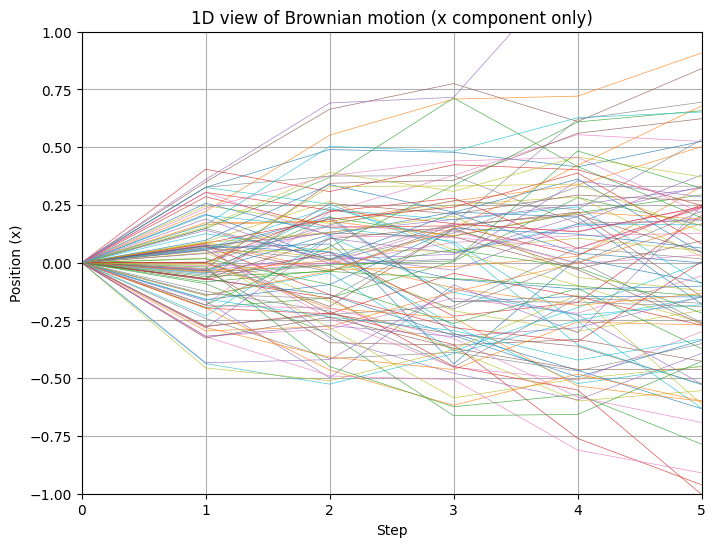

In [46]:
def simulate_brownian(n_steps=1000, dt=1/252, n_paths=1, sigma=1.0, seed=None):
    """
    Symuluje ruch Browna (2D) i zwraca pozycje.
    Zwracany kształt tablicy: (n_paths, n_steps+1, 2)
    Argumenty:
      - n_steps: liczba kroków (bez pozycji startowej)
      - dt: krok czasowy (używany tylko do skali wariancji)
      - n_paths: liczba niezależnych ścieżek
      - sigma: skala odchylenia standardowego dla przyrostów
      - seed: ziarno generatora losowego (opcjonalne)
    """
    # tworzymy generator losowy (nowy API NumPy)
    rng = np.random.default_rng(seed)
    # odchylenie standardowe przyrostu dla pojedynczego kroku: sigma * sqrt(dt)
    std = sigma * np.sqrt(dt)
    # generujemy przyrosty o kształcie (n_paths, n_steps, 2) -> DWA wymiary (x,y)
    increments = rng.normal(loc=0.0, scale=std, size=(n_paths, n_steps, 2))
    # zaczynamy od zera dla każdej ścieżki: (n_paths, 1, 2)
    starts = np.zeros((n_paths, 1, 2))
    # skumulowane pozycje: dołączamy pozycję startową, potem suma przyrostów wzdłuż osi czasu
    positions = np.concatenate([starts, np.cumsum(increments, axis=1)], axis=1)
    return positions

def plot_brownian(positions, figsize=(8,6)):
    """
    Rysuje przebiegi ruchu Browna. Funkcja spodziewa się tablicy o kształcie
    (n_paths, n_times, dim). W tej implementacji wykreślana jest pierwsza składowa (x)
    jako funkcja kroku (czyli traktujemy wykres jako 1D pozycję względem czasu).
    """
    n_paths, n_times, _ = positions.shape
    times = np.arange(n_times)
    plt.figure(figsize=figsize)
    
    # Rysujemy dla każdej ścieżki wartość x w kolejnych krokach
    for i in range(n_paths):
        # używamy składowej 0 = x; linewidth zmniejszony dla dużej liczby ścieżek
        plt.plot(times, positions[i, :, 0], alpha=0.8, label=f'path {i+1}', linewidth=.5)
    plt.xlim(0, n_times-1)
    plt.ylim(-1, 1)
    plt.xlabel('Step')          # oś pozioma: indeks kroku
    plt.ylabel('Position (x)')  # oś pionowa: pozycja (tutaj tylko x)
    plt.title('1D view of Brownian motion (x component only)')
    if n_paths <= 5:
        # pokazujemy legendę tylko gdy niewiele ścieżek, by nie zaśmiecać wykresu
        plt.legend()

    plt.grid(True)
    plt.show()
    
    
# Przykład użycia: symulujemy i rysujemy (można pominąć, jeśli używamy już istniejącej zmiennej positions)
positions = simulate_brownian(n_steps=5, dt=1/252, n_paths=100, sigma=3, seed=42)
plot_brownian(positions)

In [49]:
import numpy as np
import math

# Black-Scholes pricing and GBM simulation utilities
# Uses numpy (already imported in the notebook as `np`) and matplotlib (`plt`) if needed.


# normal CDF (vectorized). Prefer numpy's erf if available.
if hasattr(np, "erf"):
    def _norm_cdf(x):
        return 0.5 * (1.0 + np.erf(x / np.sqrt(2.0)))
else:
    _vec_erf = np.vectorize(math.erf)
    def _norm_cdf(x):
        return 0.5 * (1.0 + _vec_erf(x / np.sqrt(2.0)))


def black_scholes_price(S, K, T, r, sigma, option="call"):
    """
    Black-Scholes analytic price for European call or put.

    Arguments:
      - S:     spot price (scalar or array-like)
      - K:     strike price (scalar or array-like)
      - T:     time to maturity in years (scalar or array-like, T>0)
      - r:     risk-free rate (annual, continuously compounded)
      - sigma: volatility (annual)
      - option: 'call' or 'put'

    Returns:
      price (same shape as inputs broadcasted)
    """
    S = np.asarray(S, dtype=float)
    K = np.asarray(K, dtype=float)
    T = np.asarray(T, dtype=float)
    r = np.asarray(r, dtype=float)
    sigma = np.asarray(sigma, dtype=float)

    # avoid division by zero for T==0
    sqrtT = np.sqrt(np.maximum(T, 1e-18))
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * sqrtT)
    d2 = d1 - sigma * sqrtT

    Nd1 = _norm_cdf(d1)
    Nd2 = _norm_cdf(d2)

    if option.lower() in ("c", "call"):
        price = S * Nd1 - K * np.exp(-r * T) * Nd2
    else:
        # put via put-call parity
        price = K * np.exp(-r * T) * (1 - Nd2) - S * (1 - Nd1)

    return price


def simulate_gbm(S0, r, sigma, T, n_steps=100, n_paths=1000, seed=None):
    """
    Simulate geometric Brownian motion paths for underlying prices.

    Returns array of shape (n_paths, n_steps+1) containing S_t for t=0..n_steps.
    """
    rng = np.random.default_rng(seed)
    dt = T / n_steps
    drift = (r - 0.5 * sigma**2) * dt
    diffusion_std = sigma * np.sqrt(dt)
    increments = rng.normal(loc=drift, scale=diffusion_std, size=(n_paths, n_steps))
    logS = np.log(S0) + np.cumsum(increments, axis=1)
    logS = np.concatenate([np.full((n_paths, 1), np.log(S0)), logS], axis=1)
    return np.exp(logS)


# def mc_black_scholes_price(S0, K, T, r, sigma, option="call", n_paths=20000, n_steps=1, seed=None):
#     """
#     Monte Carlo estimator for European option (discounted payoff).
#     Returns (price_estimate, std_error).
#     """
#     paths = simulate_gbm(S0, r, sigma, T, n_steps=n_steps, n_paths=n_paths, seed=seed)
#     ST = paths[:, -1]
#     if option.lower() in ("c", "call"):
#         payoffs = np.maximum(ST - K, 0.0)
#     else:
#         payoffs = np.maximum(K - ST, 0.0)
#     discounted_mean = np.exp(-r * T) * payoffs.mean()
#     discounted_se = np.exp(-r * T) * payoffs.std(ddof=1) / np.sqrt(n_paths)
#     return discounted_mean, discounted_se


# # Example usage (won't overwrite existing `positions` variable):
# if __name__ == "__main__":
#     # parameters
#     S0 = 100.0
#     K = 100.0
#     T = 1.0
#     r = 0.05
#     sigma = 0.2

#     analytic_call = black_scholes_price(S0, K, T, r, sigma, option="call")
#     analytic_put = black_scholes_price(S0, K, T, r, sigma, option="put")

#     mc_call, se_call = mc_black_scholes_price(S0, K, T, r, sigma, option="call",
#                                               n_paths=20000, n_steps=1, seed=42)

#     print(f"Analytic Call: {analytic_call:.6f}")
#     print(f"Analytic Put:  {analytic_put:.6f}")
#     print(f"MC Call:       {mc_call:.6f}  (SE={se_call:.6f})")

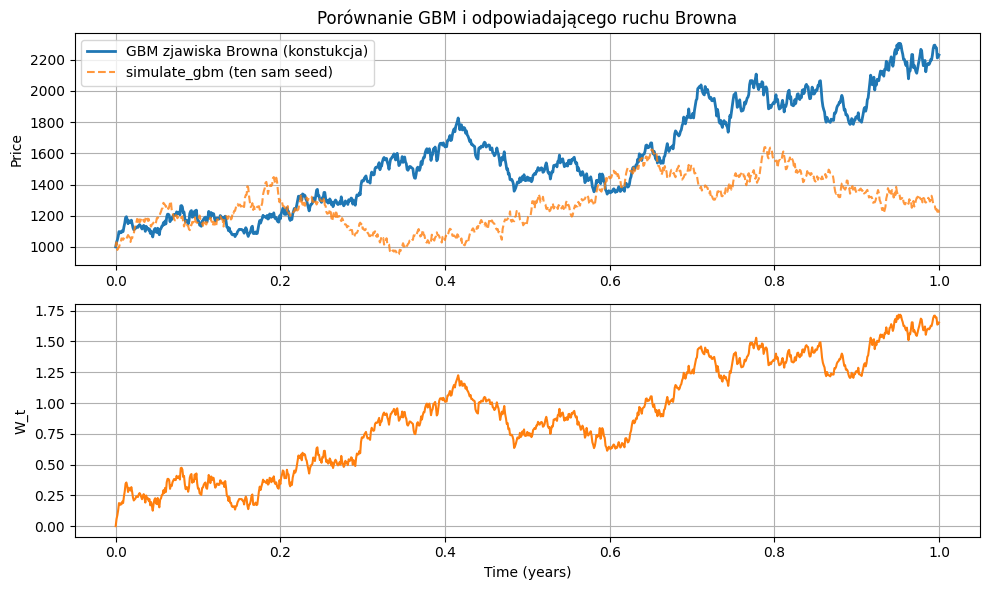

In [80]:
# Symulacja jednej ścieżki GBM z wykorzystaniem jednej ścieżki ruchu Browna
# oraz porównanie z wynikiem simulate_gbm (ten sam seed) — wykresy price i W_t.

n_steps = 1000
seed = 13
n_paths = 10000

S0 = 1000.0
K = 1000.0
T = 1.0
r = 0.1
sigma = 0.5



# użyj istniejącej funkcji simulate_brownian, generujemy standardowy Browna (sigma=1)
bm = simulate_brownian(n_steps=n_steps, dt=T / n_steps, n_paths=n_paths, sigma=1.0, seed=seed)
W = bm[0, :, 0]           # x-komponenta (kumulatywna), kształt (n_steps+1,)
times = np.linspace(0, T, n_steps + 1)

# budujemy GBM z tej ścieżki Browna:
# log S_t = log S0 + (r - 0.5 sigma^2) t + sigma * W_t
logS = np.log(S0) + (r - 0.5 * sigma**2) * times + sigma * W
S_from_W = np.exp(logS)

# porównawczo: bezpośrednia symulacja GBM z funkcji simulate_gbm (ten sam seed)
gbm_sim = simulate_gbm(S0, r, sigma, T, n_steps=n_steps, n_paths=n_paths, seed=seed)[0]

# wykresy
plt.figure(figsize=(10,6))

ax1 = plt.subplot(211)
ax1.plot(times, S_from_W, label='GBM zjawiska Browna (konstukcja)', lw=2)
ax1.plot(times, gbm_sim, '--', label='simulate_gbm (ten sam seed)', alpha=0.8)
ax1.set_ylabel('Price')
ax1.set_title('Porównanie GBM i odpowiadającego ruchu Browna')
ax1.legend()
ax1.grid(True)

ax2 = plt.subplot(212, sharex=ax1)
ax2.plot(times, W, color='C1', label='Standardowy ruch Browna W_t (x-komp.)')
ax2.set_xlabel('Time (years)')
ax2.set_ylabel('W_t')
# ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

Średnia cena na koniec (wszystkie ścieżki): 1108.703375
Odchylenie standardowe cen końcowych: 592.841835
Wartość teoretyczna E[S_T]=S0*exp(r*T): 1105.170918
Cena (zbudowana z jednej ścieżki W): 2229.797070
Cena (pierwsza ścieżka simulate_gbm): 1219.686326


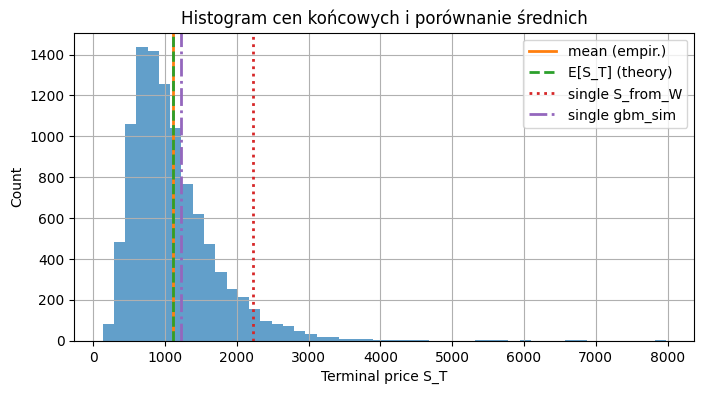

In [81]:
# Porównanie średnich cen na koniec wszystkich ścieżek
# Wykorzystujemy istniejące zmienne: bm, S0, r, sigma, T, S_from_W, gbm_sim, n_paths, times, plt

# wyciągamy składową x z bm (kształt (n_paths, n_steps+1))
W_paths = bm[:, :, 0]

# budujemy ceny GBM dla wszystkich ścieżek: S_t = S0 * exp((r-0.5*sigma^2)*t + sigma * W_t)
# times ma kształt (n_steps+1,)
log_term = (r - 0.5 * sigma**2) * times  # kształt (n_steps+1,)
S_all = S0 * np.exp(log_term[None, :] + sigma * W_paths)

# ceny końcowe, statystyki
terminal_prices = S_all[:, -1]
mean_terminal = terminal_prices.mean()
std_terminal = terminal_prices.std(ddof=1)
theoretical_mean = S0 * np.exp(r * T)

# wartości pojedynczych ścieżek dostępne w notebooku
single_from_W = S_from_W[-1]
single_gbm_sim = gbm_sim[-1]

print(f"Średnia cena na koniec (wszystkie ścieżki): {mean_terminal:.6f}")
print(f"Odchylenie standardowe cen końcowych: {std_terminal:.6f}")
print(f"Wartość teoretyczna E[S_T]=S0*exp(r*T): {theoretical_mean:.6f}")
print(f"Cena (zbudowana z jednej ścieżki W): {single_from_W:.6f}")
print(f"Cena (pierwsza ścieżka simulate_gbm): {single_gbm_sim:.6f}")

# histogram cen końcowych z liniami pokazującymi średnie/teorię
plt.figure(figsize=(8,4))
plt.hist(terminal_prices, bins=50, alpha=0.7, density=False, color='C0')
plt.axvline(mean_terminal, color='C1', linestyle='-', lw=2, label='mean (empir.)')
plt.axvline(theoretical_mean, color='C2', linestyle='--', lw=2, label='E[S_T] (theory)')
plt.axvline(single_from_W, color='C3', linestyle=':', lw=2, label='single S_from_W')
plt.axvline(single_gbm_sim, color='C4', linestyle='-.', lw=2, label='single gbm_sim')
plt.xlabel('Terminal price S_T')
plt.ylabel('Count')
plt.title('Histogram cen końcowych i porównanie średnich')
plt.legend()
plt.grid(True)
plt.show()

MC (GBM) call price (empir.): 241.716850  (SE = 4.297599, n=10000)
Black-Scholes analytic call: 239.267448
Różnica (MC - BS): 2.449401


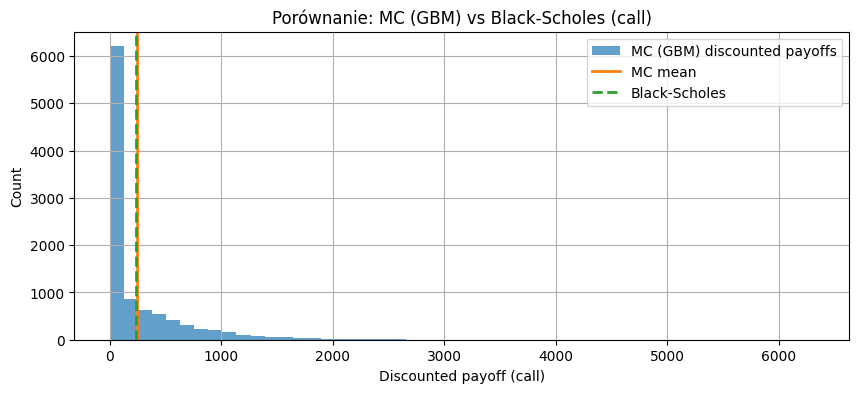

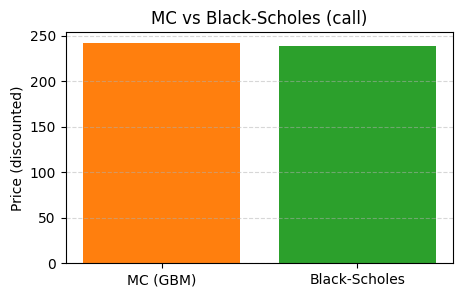

In [82]:
# Porównanie tylko MC (GBM) vs Black-Scholes (call)
# Wykorzystuje istniejące zmienne: terminal_prices, S0, K, T, r, sigma, black_scholes_price, plt, np

# estymator Monte Carlo (z symulacji GBM/WM już przechowywanych w terminal_prices)
payoffs = np.maximum(terminal_prices - K, 0.0)
discounted_payoffs = np.exp(-r * T) * payoffs

mc_call_price = discounted_payoffs.mean()
mc_call_se = discounted_payoffs.std(ddof=1) / np.sqrt(discounted_payoffs.size)

# analityczna cena Black-Scholes
bs_call_price = black_scholes_price(S0, K, T, r, sigma, option="call")

# wydruki (PL)
print(f"MC (GBM) call price (empir.): {mc_call_price:.6f}  (SE = {mc_call_se:.6f}, n={discounted_payoffs.size})")
print(f"Black-Scholes analytic call: {bs_call_price:.6f}")
print(f"Różnica (MC - BS): {mc_call_price - bs_call_price:.6f}")

# Histogram zdyskontowanych payoffów z liniami porównawczymi
plt.figure(figsize=(10,4))
plt.hist(discounted_payoffs, bins=50, alpha=0.7, color='C0', label='MC (GBM) discounted payoffs')
plt.axvline(mc_call_price, color='C1', lw=2, linestyle='-', label='MC mean')
plt.axvline(bs_call_price, color='C2', lw=2, linestyle='--', label='Black-Scholes')
plt.xlabel('Discounted payoff (call)')
plt.ylabel('Count')
plt.title('Porównanie: MC (GBM) vs Black-Scholes (call)')
plt.legend()
plt.grid(True)
plt.show()

# Prosty wykres słupkowy porównujący wartości cen
plt.figure(figsize=(5,3))
labels = ['MC (GBM)', 'Black-Scholes']
values = [mc_call_price, bs_call_price]
plt.bar(labels, values, color=['C1','C2'])
plt.ylabel('Price (discounted)')
plt.title('MC vs Black-Scholes (call)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


zaimplementowac cene opcji call, cene opcji put, black scholes